In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as s
import datetime as datetime
df = pd.read_csv("C:/Users/Manas Tiwari/Desktop/air.csv", encoding="latin1", low_memory=False)
df.info()

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Manas Tiwari/Desktop/air.csv'

# Drop useless columns

In [12]:
df.drop(["license","house_rules"],axis = 1,inplace=True)

# Change datatype of important columns

In [59]:
df["last review"] = pd.to_datetime(df["last review"],errors="coerce") 
df["price"]= df["price"].replace(r"[\$,]","",regex = True).astype(float)
df["service fee"]= df["service fee"].replace(r"[\$,]","",regex = True).astype(float)


# Fill some null value inthe required columns

In [36]:
df.fillna({"reviews per month" : 0,"last review": df["last review"].min()},inplace = True)

# Drop nullvalue

In [42]:
df.dropna(subset = ["NAME","host name"],inplace = True)

# Drop duplicates_value

In [62]:
df.drop_duplicates(inplace = True)

# Q.1 : distribution of listing price ??

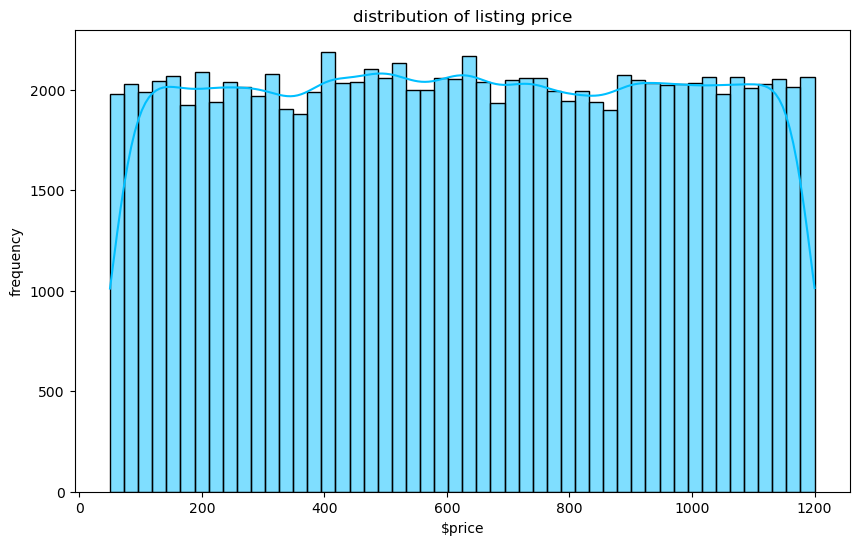

In [87]:
plt.figure(figsize = (10,6))
s.histplot(df["price"],bins = 50,kde = True, color="deepskyblue")
plt.title("distribution of listing price")
plt.xlabel("$price")
plt.ylabel("frequency")
plt.show()

conclusion : The distribution of listing prices is nearly uniform, with prices spread fairly evenly across the entire range, indicating no strong price clustering in the dataset.

# Q.2 : how are diffrent room types distributed ??

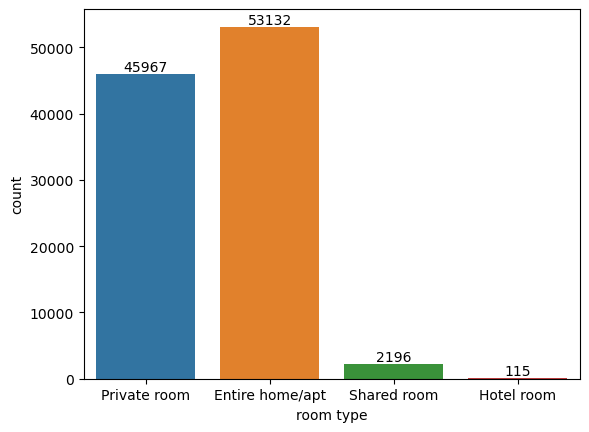

In [102]:
a = s.countplot(df, x="room type", hue="room type", palette="tab10", legend=False)
for bars in a.containers:
    a.bar_label(bars)

conclusion : The majority of listings are for Entire home/apt (53,132) and Private rooms (45,967), showing a strong preference for more private accommodations.
Shared rooms and Hotel rooms are significantly less common, indicating lower demand or availability.

# Q.3 : how are listing distributed across diffrent neighbourhood ??


Text(0.5, 0, 'frequency')

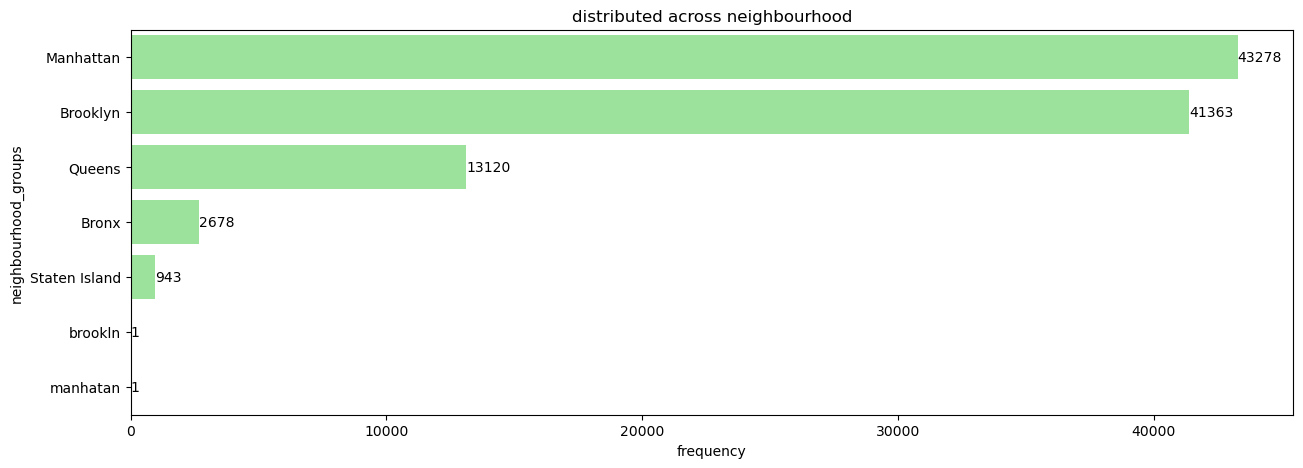

In [134]:
plt.figure(figsize = (15,5))
a = s.countplot(df,y = "neighbourhood group",color = "lightgreen",order = df["neighbourhood group"].value_counts().index)
for bars in a.containers:
    a.bar_label(bars)
plt.title("distributed across neighbourhood")
plt.ylabel("neighbourhood_groups")
plt.xlabel("frequency")

conclusion : Most listings are concentrated in Manhattan and Brooklyn, while other areas like Queens, Bronx, and Staten Island have significantly fewer entries.

# Q.4 : what is the relationship between room type and price ??


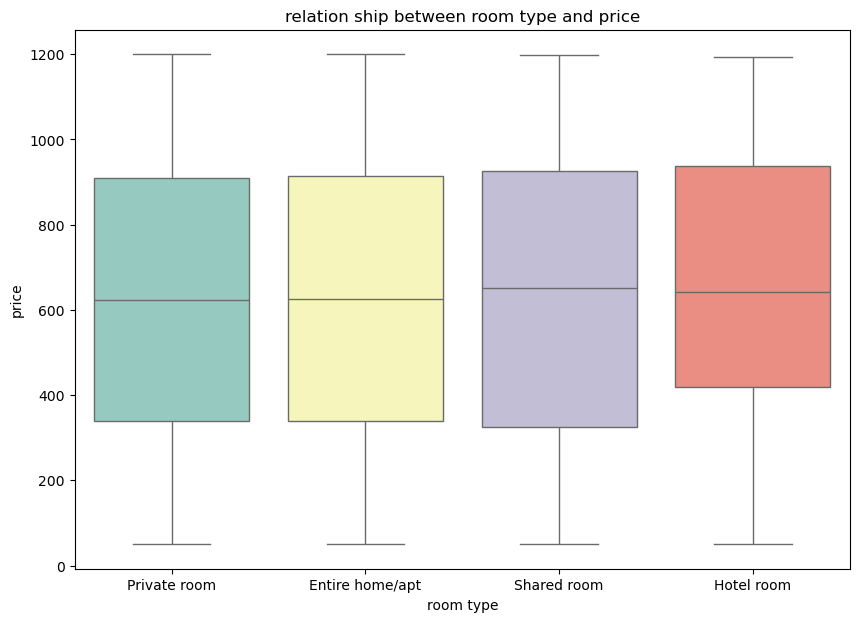

In [190]:
plt.figure(figsize = (10,7))
s.boxplot(df,x = "room type",y = "price", hue="room type", palette="Set3",legend = False)
plt.title("relation ship between room type and price")
plt.ylabel("price")
plt.xlabel("room type")
plt.show()

concusion : All room types show a wide range of prices with similar median values, suggesting comparable pricing overall.
However, the price variability is high across all categories, indicating inconsistent pricing strategies among listings.

# Q.5 : how has the reviwes change over the time ??

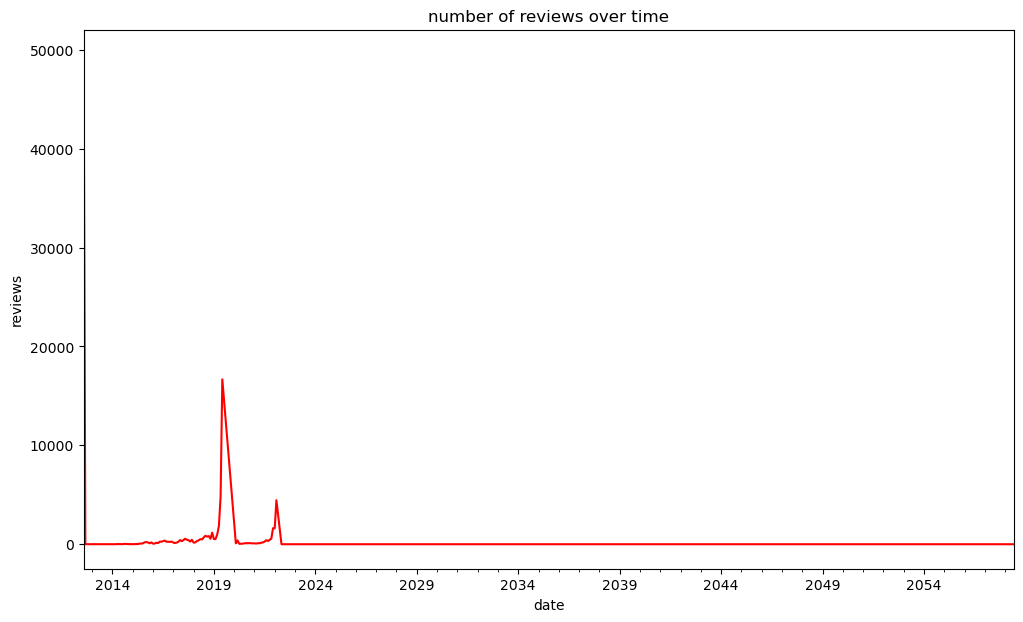

In [203]:
plt.figure(figsize = (12,7))
rv = df.groupby(df["last review"].dt.to_period("M")).size()
rv.plot(kind = "line",color = "red")
plt.title("number of reviews over time")
plt.ylabel("reviews")
plt.xlabel("date")
plt.show()


conclusion : The number of reviews peaked sharply around 2019–2020, followed by a noticeable drop and steady decline.
Activity after 2022 is minimal, suggesting reduced engagement or missing data in later years.

# Final Conclusion : The majority of listings are concentrated in Manhattan and Brooklyn, with Entire home/apartment and Private rooms being the most preferred room types. Price distribution is wide across all room types, indicating inconsistent pricing but similar medians. Reviews peaked sharply around 2019–2020, followed by a noticeable decline, possibly due to market changes or data limitations after 2022. Overall, user engagement and activity were highest pre-2020, with Manhattan and private spaces dominating the market.